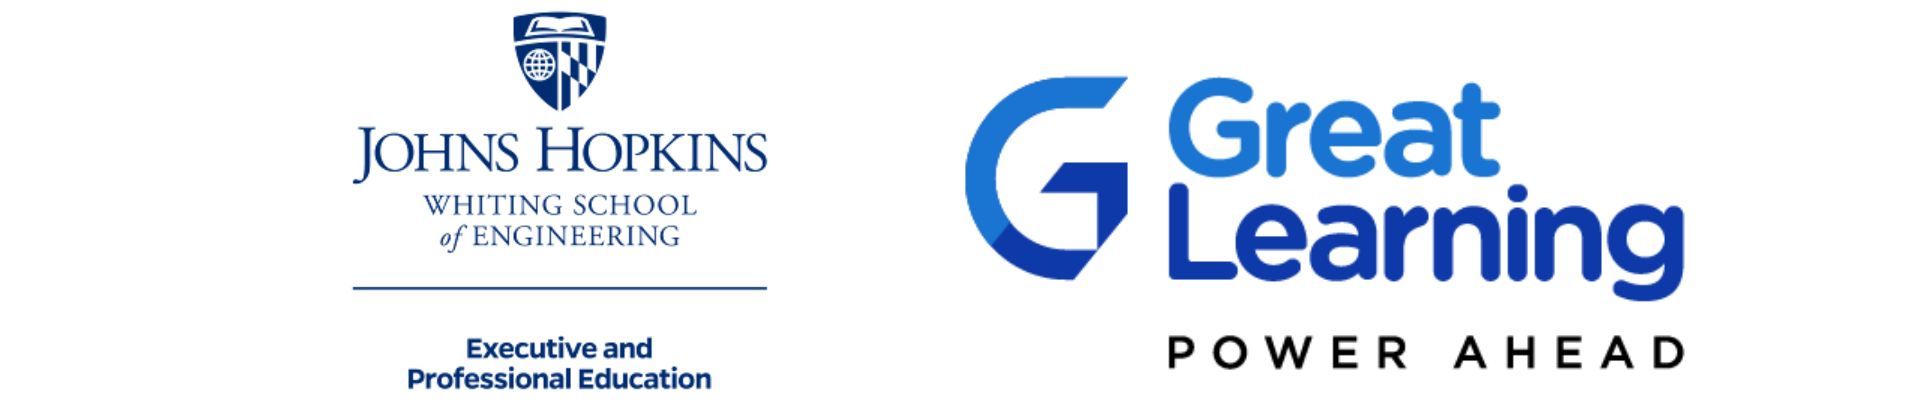

# **Insurance Claim - Multi-Agent System (MAS)**
### *Heuristic Risk Assessment Using MAS for Insurance Claims*

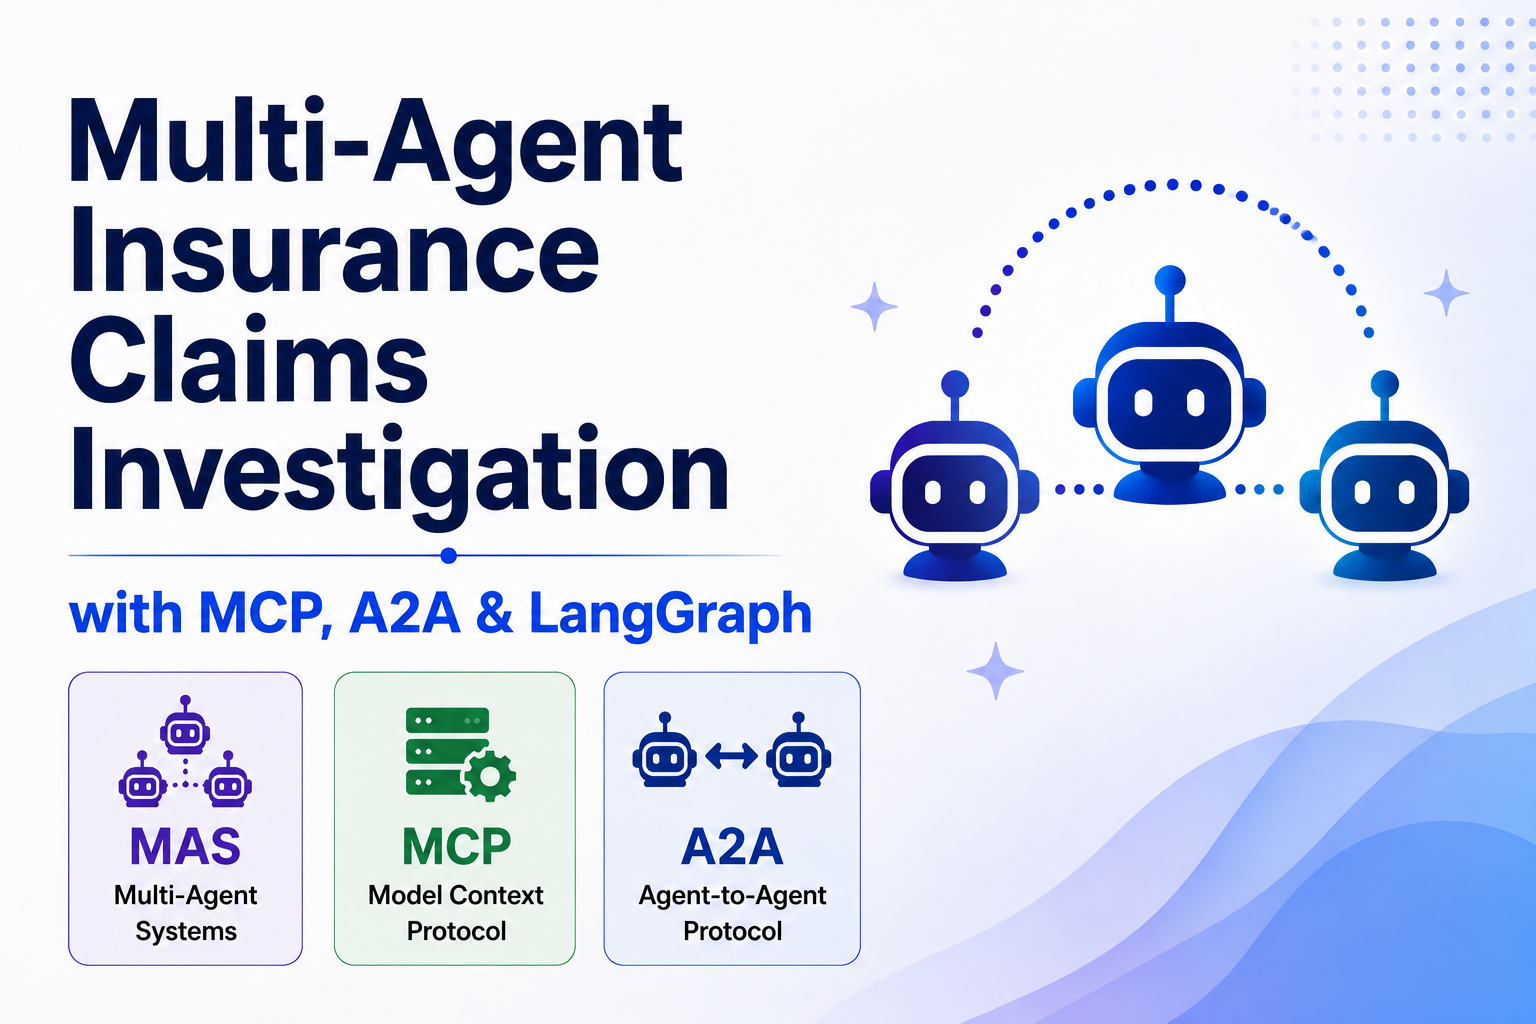

### **Problem Statement**
Insurance claim operations need fast, consistent risk triage. Manual review is costly, subjective, and hard to scale, while purely deterministic rules miss context and can fail on partial evidence.

### **Proposed Solution**
Build a multi-agent claim-risk assessment workflow where specialized worker services collect evidence from structured data/documents, and a critic service produces a bounded, auditable risk verdict.

### **Approach**
- Use a deterministic LangGraph orchestrator to dispatch and control retries.
- Use three role-specific A2A worker services: consistency, history, and documents.
- Use MCP-backed tools for evidence retrieval from synthetic CSV/PDF sources.
- Aggregate evidence with quorum checks, then evaluate through a critic with explicit disagreement/evidence-gap criteria.
- Produce final APPROVE/DENY decisions with an append-only audit trail.



**Stack:** LangGraph + LangChain-OpenAI + MCP SDK (`mcp==1.12.4`) + A2A SDK (`a2a-sdk==1.1.2`)

The workflow demonstrates a **Supervisor/Orchestrator -> Worker Agents -> Critic Agent** pattern for *synthetic* insurance-claim triage.

- **Orchestrator (deterministic router):** dispatches worker-agent calls, enforces retry caps, and applies the critic decision (**no LLM here**).
- **3 worker services (A2A):** `consistency-agent`, `history-agent`, and `documents-agent` run as independent A2A endpoints in the active runtime.
- **Aggregator:** merges worker-service outputs into a fixed-shape `AggregatedClaimReport` TypedDict.
- **Critic service (A2A):** exposed as a separate **local HTTP service** and returns a structured verdict via the A2A task lifecycle.
- **Bounded re-evaluation loop:** the compiled graph is **cyclic** (for retries), even though each forward pass is DAG-shaped.
- **Safety controls (synthetic):** timeouts, partial-failure handling, and a conservative quorum policy.
- **Audit trail:** append-only log in state (LangGraph reducer).

**Protocol boundaries (what to learn)**
- `LangGraph`: in-process orchestration, state, reducers, bounded retries.
- `MCP`: standardized protocol boundary through which workers call server-exposed tools.
- `A2A`: standardized inter-agent protocol. The orchestrator acts as an A2A client to call worker services and the critic service.

---

The workflow demonstrates multi-agent evidence assessment and heuristic claim-risk scoring on **Synthetic Data**.

**Orchestrator note:** an orchestrator can be deterministic code or an agent. This implementation uses deterministic code.

Output values can vary across runs.


## **Architecture**

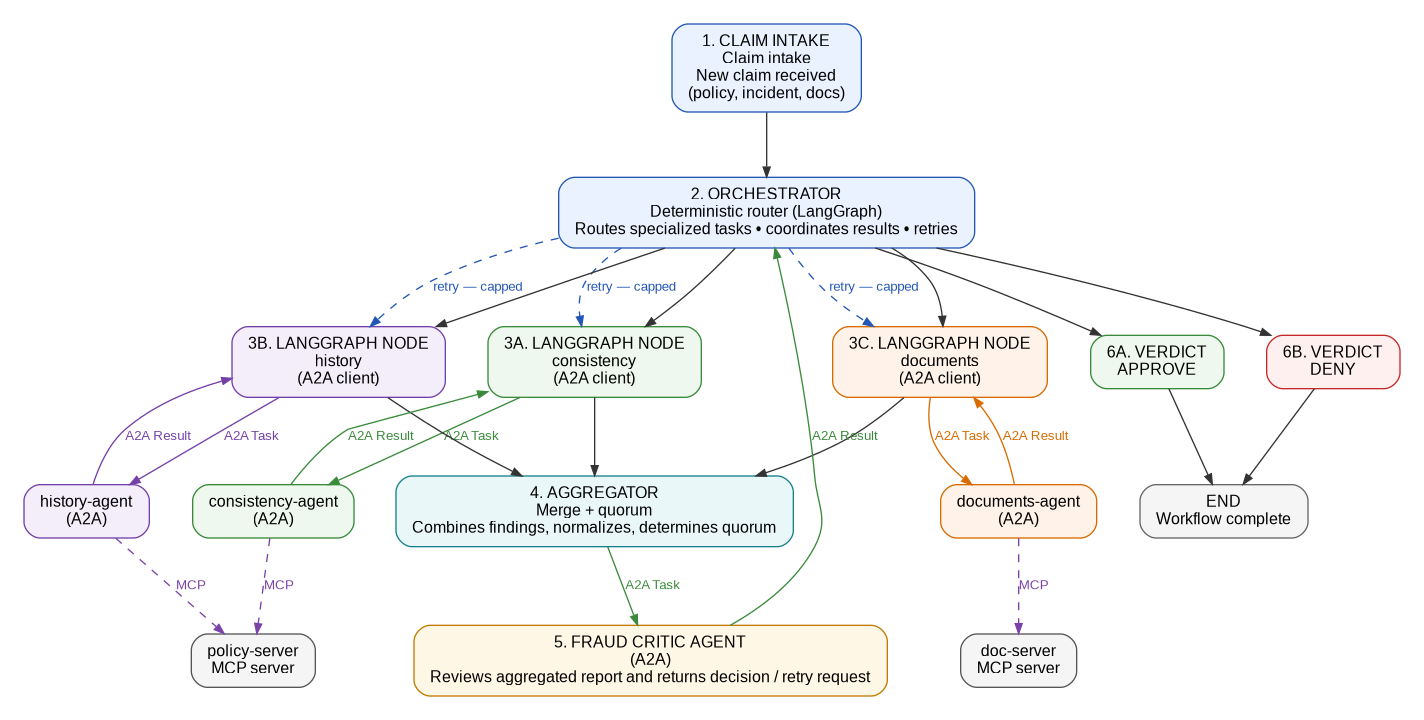

**Notes:**
- MCP and A2A services run on `127.0.0.1` inside the active runtime. Ports are allocated dynamically and printed when services start.
- The implementation uses multiple **A2A-compliant specialized agent services** with fixed role-specific execution logic, coordinated by LangGraph.
- The overall compiled graph contains a bounded cycle for retries (it is not a pure DAG).

**Parallelism vs MAS (important distinction)**

| Pattern | MAS? | Why |
|---|---|---|
| 3 parallel LLM calls | Not necessarily | Parallelism alone does not create role boundaries or protocol-based collaboration. |
| 3 LangGraph nodes in parallel | Not necessarily | This can still be a pure workflow pattern without distinct agent services. |
| 3 role-specific A2A services coordinated by an orchestrator | Yes (current structure) | Specialized capabilities + A2A interaction boundaries + orchestrated collaboration. |


## References

Patterns and code idioms borrowed (and lightly adapted) from:

| # | Source | What we use |
|---|---|---|
| 1 | [LangGraph - State & Reducers](https://docs.langchain.com/oss/python/langgraph/graph-api#reducers) | `Annotated[dict, merger]` and `Annotated[list, operator.add]` reducers for parallel writes |
| 2 | [LangGraph - Branching / conditional edges](https://docs.langchain.com/oss/python/langgraph/workflows-agents#routing) | `add_conditional_edges` returning node names for parallel dispatch |
| 3 | [LangChain - Structured output](https://docs.langchain.com/oss/python/langchain/structured-output) | `llm.with_structured_output(PydanticModel)` for worker/critic outputs |
| 4 | [A2A Protocol Specification](https://a2a-protocol.org/latest/specification/) | Agent Card discovery + SendMessage/Task lifecycle concepts |
| 5 | [Model Context Protocol Specification (2025-06-18)](https://modelcontextprotocol.io/specification/2025-06-18) | Streamable-HTTP + initialization behavior aligned with the pinned MCP SDK used in this implementation |


## 1. Install dependencies

Versions are **pinned intentionally** for this course workflow. Package upgrades require a clean-kernel re-run and MCP/A2A plumbing re-validation (these APIs evolve quickly).

Prerequisites
- Provide OpenAI credentials via env vars (`OPENAI_API_KEY`, optional `OPENAI_BASE_URL`).
- Dependency install below auto-selects a pinned **Colab** vs **Local** package set.


In [1]:
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules

CORE_PACKAGES = [
    "mcp==1.12.4",
    "a2a-sdk==1.1.2",
    "langgraph==0.3.34",
    "langchain==0.3.27",
    "langchain-openai==0.3.9",
    "openai==1.66.3",
    "fastapi==0.115.12",
    "uvicorn==0.34.2",
    "httpx==0.28.1",
    "pydantic==2.11.3",
    "pandas==3.0.3",
    "pypdf==5.4.0",
    "reportlab==5.0.0",
]

# Keep separate buckets so Colab/Local can evolve independently.
COLAB_PACKAGES = [
    "nest_asyncio==1.6.0",
]
LOCAL_PACKAGES = []

target = "Colab" if IN_COLAB else "Local"
packages = CORE_PACKAGES + (COLAB_PACKAGES if IN_COLAB else LOCAL_PACKAGES)
print(f"Installing {target} dependency set ({len(packages)} packages)...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])
print("Dependency installation complete.")

Installing Colab dependency set (14 packages)...
Dependency installation complete.


## 2. Imports and LLM

One LLM (`gpt-4o-mini`, `temperature=0`) is used to **reduce variability** across runs (still not guaranteed deterministic).


In [2]:
import os, json, asyncio, threading, time, uuid, operator, logging
from datetime import datetime, timezone, date
from pathlib import Path
from typing import TypedDict, Annotated, Optional, Any, Literal

import httpx
import pandas as pd
import uvicorn
from pydantic import BaseModel, Field, field_validator
from pypdf import PdfReader
from starlette.applications import Starlette

from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client
from mcp.server.fastmcp import FastMCP

from a2a import types as a2a_types
from a2a.client import A2ACardResolver, ClientFactory, ClientConfig
from a2a.server.agent_execution import AgentExecutor, RequestContext
from a2a.server.events import EventQueue
from a2a.server.request_handlers import DefaultRequestHandler
from a2a.server.routes import create_agent_card_routes, create_jsonrpc_routes
from a2a.server.tasks import InMemoryTaskStore, TaskUpdater

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# VS Code / Windows notebook compatibility; harmless on Colab/Linux.
if os.name == "nt":
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# MCP/HTTPX can be chatty inside notebooks (incl. benign ClosedResourceError traces on stream shutdown).
for _name in [
    "mcp",
    "mcp.server",
    "mcp.server.streamable_http",
    "mcp.server.streamable_http_manager",
    "httpx",
    "httpcore",
]:
    logging.getLogger(_name).setLevel(logging.CRITICAL)


/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
# ---- API configuration ------------------------------------------------------
# Configuration: place config.json in the working directory before running this cell.

with open("config.json", "r") as f:
    config = json.load(f)

os.environ["OPENAI_API_KEY"] = config["API_KEY"]
os.environ["OPENAI_API_BASE"] = config["OPENAI_API_BASE"]

print("Using OPENAI credentials from environment variables only.")

Using OPENAI credentials from environment variables only.


In [4]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print(f"LLM initialized: {llm.model_name}")
print("Note: temperature=0 is near-deterministic, not guaranteed deterministic.")
print("For reproducibility, pin model version and log seed + system_fingerprint when available.")

LLM initialized: gpt-4o-mini
Note: temperature=0 is near-deterministic, not guaranteed deterministic.
For reproducibility, pin model version and log seed + system_fingerprint when available.


In [5]:
# Test the LLM invocation
llm.invoke("Hello, world!").content

'Hello! How can I assist you today?'

## 3. Loading the data

- **`data/policies.csv`** - 10 policy records
- **`data/claim_history.csv`** - 17 historical claim entries
- **`data/repair_shops.csv`** - 6 repair-shop registry entries
- **`data/claims.csv`** - 10 current claims for processing
- **`data/documents/CLM-*.pdf`** - one invoice PDF per claim (10 PDFs), with a few **synthetic inconsistencies**

  
  - `CLM-4003.pdf` - claim_id printed in the header does **not** match the claim_id in the body (content inconsistency)
  - `CLM-4004.pdf` - amount printed on the invoice does **not** match `claims.csv` (content inconsistency)
  - `CLM-4008.pdf` - `/Producer` metadata differs from the fabricated ground truth dataset (metadata inconsistency)

The MCP servers below read from these files, so they behave as local synthetic file-backed services (not database-backed production services). Any file can be opened to inspect the synthetic ground truth.

In [6]:
import zipfile
from pathlib import Path

# Ensure the data directory exists
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DOCS_DIR = DATA_DIR / "documents"

zip_file_path = Path("Insurance_claims_data.zip")

if zip_file_path.exists():
    print(f"Extracting {zip_file_path.name} to {DATA_DIR}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print(f"Zip file not found at {zip_file_path}. Skipping extraction.")

Extracting Insurance_claims_data.zip to data...
Extraction complete.


### Verify the data files

In [7]:
# Read the CSVs back and confirm shapes
_policies  = pd.read_csv(DATA_DIR / "policies.csv")
_history   = pd.read_csv(DATA_DIR / "claim_history.csv")
_shops     = pd.read_csv(DATA_DIR / "repair_shops.csv")
_claims    = pd.read_csv(DATA_DIR / "claims.csv")

assert len(_policies) == 10, f"expected 10 policies, got {len(_policies)}"
assert len(_history)  == 17, f"expected 17 history rows, got {len(_history)}"
assert len(_shops)    == 6,  f"expected 6 shops, got {len(_shops)}"
assert len(_claims)   == 10, f"expected 10 claims, got {len(_claims)}"
assert len(list(DOCS_DIR.glob("*.pdf"))) == 10, "expected 10 PDFs"

_claims.head()


,claim_id,policy_id,policyholder_id,amount,incident_date,incident_location,repair_shop_id,vehicle,narrative
0,CLM-4001,POL-001,PH-100,2800,2026-07-14,"Newark, NJ",SHOP-001,2019 Toyota Camry,Rear-ended at a traffic light on Broad Street ...
1,CLM-4002,POL-005,PH-500,3400,2026-07-20,"Portland, OR",SHOP-003,2022 Subaru Outback,Struck by falling branch during storm. Roof an...
2,CLM-4003,POL-003,PH-300,14500,2026-08-02,"Miami, FL",SHOP-999,2021 BMW X5,Vehicle totaled after flooding during heavy st...
3,CLM-4004,POL-010,PH-999,9500,2026-08-08,"Las Vegas, NV",SHOP-999,2017 Nissan Altima,Hit and run in casino parking lot. Extensive d...
4,CLM-4005,POL-002,PH-200,4900,2026-08-10,"Denver, CO",SHOP-002,2020 Honda Civic,Minor fender-bender in grocery store parking l...


## 4. MCP servers

Two MCP servers, each backed by local synthetic files:
- **`policy-server`** reads `policies.csv` and `claim_history.csv`.
- **`doc-server`** reads PDFs in `data/documents/` and `repair_shops.csv`.

MCP role in this implementation:
- MCP is the standardized protocol boundary between a client/host and capability servers.
- MCP servers can expose tools/resources/prompts; this implementation uses MCP **tools**.
- Both servers use the real MCP Python SDK over streamable-HTTP transport.

For this pinned SDK path (`mcp==1.12.4`), the client helper calls `session.initialize()` before tool calls.


In [8]:
# ---- Real MCP servers via MCP SDK ------------------------------------------
policy_mcp = FastMCP("policy-server", stateless_http=True, json_response=True)
doc_mcp = FastMCP("doc-server", stateless_http=True, json_response=True)

/usr/local/lib/python3.12/dist-packages/pydantic_settings/sources/utils.py:47: IncompleteFieldDefinitionWarning: Field 'lifespan' has an incomplete definition: its annotation contains an unresolved forward reference, so settings sources may fail to correctly resolve its value. Call `model_rebuild()` on the model where the field is defined, once all the referenced types are defined.
  warnings.warn(


### `policy-server` - reads `policies.csv` and `claim_history.csv`

In [9]:
@policy_mcp.tool()
def get_policy_details(policy_id: str) -> dict:
    """MCP tool: return the policy record for a `policy_id`."""

    df = pd.read_csv(DATA_DIR / "policies.csv")
    hit = df[df["policy_id"] == policy_id]
    if hit.empty:
        raise ValueError(f"policy {policy_id} not found")
    return hit.iloc[0].to_dict()


@policy_mcp.tool()
def get_claim_history(policyholder_id: str) -> list:
    """MCP tool: return past claims for a given `policyholder_id`."""

    df = pd.read_csv(DATA_DIR / "claim_history.csv")
    return df[df["policyholder_id"] == policyholder_id].to_dict(orient="records")


### `doc-server` - reads the PDF invoices and `repair_shops.csv`

Uses `pypdf` to extract text and PDF metadata. The document check compares simple **consistency signals** against the synthetic ground truth dataset:

1. Does the claim_id printed on the invoice match the requested claim_id?
2. Does the amount on the invoice match `claims.csv`?
3. Does the `/Producer` metadata match the fabricated expectation dataset? *(Auxiliary consistency check - metadata alone is insufficient for provenance.)*

Adapted from the pypdf extraction example: https://pypdf.readthedocs.io/en/stable/user/extract-text.html


In [10]:
def _parse_invoice(pdf_path: Path) -> dict:
    """Extract invoice text and a few PDF metadata fields."""

    reader = PdfReader(str(pdf_path))
    meta = reader.metadata or {}
    text = "\n".join(p.extract_text() or "" for p in reader.pages)
    return {
        "text": text,
        "producer": str(meta.get("/Producer", "")),
        "author": str(meta.get("/Author", "")),
        "title": str(meta.get("/Title", "")),
    }


@doc_mcp.tool()
def check_document_consistency(claim_id: str) -> dict:
    """Synthetic document-consistency checks (auxiliary signals).

    Important: this is **not** real document forensics. We compare extracted
    content/metadata to the notebook's fabricated ground truth (claims.csv).
    """

    pdf_path = DOCS_DIR / f"{claim_id}.pdf"
    if not pdf_path.exists():
        return {"claim_id": claim_id, "status": "missing", "anomaly_indicators": ["file_not_found"]}

    parsed = _parse_invoice(pdf_path)
    expected = pd.read_csv(DATA_DIR / "claims.csv").query("claim_id == @claim_id").iloc[0].to_dict()

    indicators = []

    # 1) Content checks
    if claim_id not in (parsed["text"].splitlines()[0] if parsed["text"] else ""):
        indicators.append("header_claim_id_mismatch")

    if f"${int(expected['amount']):,}" not in parsed["text"]:
        indicators.append("amount_mismatch")

    # 2) Metadata check (auxiliary signal only)
    if "ReportLab" not in parsed["producer"]:
        indicators.append(f"unexpected_producer:{parsed['producer']}")

    return {
        "claim_id": claim_id,
        "status": "ok",
        "producer": parsed["producer"],
        "author": parsed["author"],
        "title": parsed["title"],
        "anomaly_indicators": indicators,
        "text_length": len(parsed["text"]),
    }


@doc_mcp.tool()
def get_repair_shop_registry(shop_id: str) -> dict:
    """MCP tool: return repair shop registry info from `repair_shops.csv`."""

    df = pd.read_csv(DATA_DIR / "repair_shops.csv")
    hit = df[df["shop_id"] == shop_id]
    if hit.empty:
        return {"shop_id": shop_id, "registered": False}

    row = hit.iloc[0].to_dict()
    row["registered"] = True

    # Normalize NaNs for notebook-friendly downstream prompting.
    if pd.isna(row.get("complaints")):
        row["complaints"] = ""

    return row


### Launch the MCP servers and wait for readiness

Uvicorn's programmatic-run pattern (`uvicorn.Server(uvicorn.Config(...))`) is documented at https://uvicorn.dev/deployment/#running-programmatically.

Runtime environments (VSCode + Colab) sometimes start background threads without a default asyncio event loop, so the launch helper:

- creates an event loop inside the thread,
- runs `server.serve()` on that loop,
- waits for `server.started` (readiness), and
- is **idempotent** on re-runs: if a prior thread is still alive, we reuse it.

Runtime startup notes (common troubleshooting patterns)

1. `RuntimeError: Service did not open port: <port>`
   - The background server thread likely crashed (or the port was taken).
   - Restart the kernel/runtime and re-run from the top.

2. `RuntimeError("There is no current event loop in thread ...")`
   - This happens when an async server is started in a thread without an asyncio event loop.
   - The `serve_in_thread()` helper explicitly creates and sets a loop inside the thread.

3. `RuntimeError: Service did not become ready: http://127.0.0.1:<port>/mcp`
   - Avoid probing `/mcp` with a plain browser-style GET. MCP's streamable HTTP transport expects a JSON-RPC handshake and can return `406`.
   - Prefer `server.started` (below) or the MCP client helper (`mcp_call`) to verify readiness.

4. `ClosedResourceError` in logs
   - This is a known noisy log path in `mcp.server.streamable_http` when streams shut down.
   - The imports cell sets those loggers to `CRITICAL` to keep output readable.


In [11]:
import socket
import traceback


def _free_port() -> int:
    """Return an available localhost port by asking the OS for one."""

    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.bind(("127.0.0.1", 0))
        return sock.getsockname()[1]


def serve_in_thread(app: Any, port: int):
    """Run a local ASGI service on a background thread.

    Why this shape?
    - Notebook runtimes (VSCode + Colab) sometimes start threads without an asyncio loop.
    - Running `Server.serve()` on an explicit loop avoids "no current event loop" failures.

    Returns `(server, thread, crash)` where `crash` is populated if the thread errors.
    """

    config = uvicorn.Config(
        app,
        host="127.0.0.1",
        port=port,
        loop="asyncio",  # avoid uvloop differences across environments
        log_level="error",
        access_log=False,
    )
    server = uvicorn.Server(config)

    crash: dict[str, str] = {}

    def _run() -> None:
        """Thread target: run the uvicorn server until `should_exit`."""

        loop = asyncio.new_event_loop()
        try:
            asyncio.set_event_loop(loop)
            loop.run_until_complete(server.serve())
        except BaseException as e:
            crash["error"] = repr(e)
            crash["traceback"] = traceback.format_exc()
        finally:
            try:
                asyncio.set_event_loop(None)
            except Exception:
                pass
            try:
                loop.close()
            except Exception:
                pass

    thread = threading.Thread(target=_run, daemon=True, name=f"uvicorn:{port}")
    thread.start()
    return server, thread, crash


def wait_server_started(server, thread, label: str, crash: dict, timeout: float = 45.0) -> None:
    """Block until uvicorn reports `server.started`, or raise on crash/timeout."""

    deadline = time.time() + timeout
    while time.time() < deadline:
        if getattr(server, "started", False):
            return
        if not thread.is_alive():
            detail = crash.get("traceback") or crash.get("error") or "unknown"
            raise RuntimeError(f"{label} server thread exited before startup:\n{detail}")
        time.sleep(0.2)
    raise RuntimeError(f"{label} server did not report started in {timeout}s")


def wait_http_ok(url: str, ok_codes=(200, 405, 406), timeout: float = 30.0) -> str:
    """Poll `url` with GET until the status code is acceptable.

    Note: do not use this against `/mcp`; MCP expects a JSON-RPC handshake and
    plain GETs can produce `406` and noisy logs.
    """

    deadline = time.time() + timeout
    while time.time() < deadline:
        try:
            r = httpx.get(url, timeout=1)
            if r.status_code in ok_codes:
                return "ready"
        except Exception:
            pass
        time.sleep(0.2)
    raise RuntimeError(f"Service did not become ready: {url}")


def start_local_service(
    app: Any,
    label: str,
    path: Optional[str] = None,
    ok_codes=(200, 405, 406),
    attempts: int = 6,
):
    """Start an ASGI app on a free port (with retries) and return `(port, server, thread)`."""

    last_error = None
    last_port = None

    for _ in range(attempts):
        port = _free_port()
        last_port = port
        server, thread, crash = serve_in_thread(app, port)

        try:
            wait_server_started(server, thread, label, crash)
        except RuntimeError as e:
            last_error = str(e)
            continue

        if path is not None:
            wait_http_ok(f"http://127.0.0.1:{port}{path}", ok_codes=ok_codes)

        print(f"[UP] {label:<13}:{port}  ready")
        return port, server, thread

    raise RuntimeError(
        f"{label} failed to start after {attempts} attempts (last_port={last_port}). Last error: {last_error}"
    )


# Idempotent cell re-runs: reuse the existing background servers if they are still running.
CRITIC_PORT = globals().get("CRITIC_PORT") or _free_port()

_policy_thread = globals().get("_policy_thread")
_policy_server = globals().get("_policy_server")
_policy_running = bool(_policy_thread) and _policy_thread.is_alive()

_doc_thread = globals().get("_doc_thread")
_doc_server = globals().get("_doc_server")
_doc_running = bool(_doc_thread) and _doc_thread.is_alive()

if _policy_running:
    print(f"[UP] policy-server :{POLICY_PORT}  (already running)")
else:
    POLICY_PORT, _policy_server, _policy_thread = start_local_service(
        policy_mcp.streamable_http_app(), "policy-server"
    )

if _doc_running:
    print(f"[UP] doc-server    :{DOC_PORT}  (already running)")
else:
    DOC_PORT, _doc_server, _doc_thread = start_local_service(
        doc_mcp.streamable_http_app(), "doc-server"
    )


[UP] policy-server:43667  ready
[UP] doc-server   :51359  ready


### MCP client helper

In [12]:
async def mcp_call(port: int, tool: str, arguments: dict) -> Any:
    """Call an MCP tool via the Streamable HTTP transport.

    Note: when `FastMCP(..., json_response=True)` returns a list, the MCP SDK
    serializes it as *multiple* `TextContent` items (one per element). This helper
    normalizes that to a Python `list` of parsed objects.
    """

    url = f"http://127.0.0.1:{port}/mcp"
    async with streamablehttp_client(url) as (read_stream, write_stream, _):
        async with ClientSession(read_stream, write_stream) as session:
            await session.initialize()
            result = await session.call_tool(tool, arguments)

            parsed = []
            for item in result.content or []:
                if getattr(item, "text", None) is not None:
                    parsed.append(json.loads(item.text))

            if len(parsed) == 1:
                return parsed[0]
            return parsed


## 5. A2A Agents - Worker Agents + Critic Agent (local services)

The implementation exposes **four A2A agents** as separate local HTTP services:
1. `consistency-agent`
2. `history-agent`
3. `documents-agent`
4. `fraud-critic`

Each agent:
- publishes an **Agent Card** at `/.well-known/agent-card.json`,
- accepts A2A SendMessage requests via the SDK's JSON-RPC routes,
- returns a completed **Task** with artifact payload.

MAS structure note:
- The orchestrator stays deterministic and acts as an **A2A client**.
- Worker reasoning/tool-use happens inside worker services.
- Critic reasoning happens inside the critic service.

Security note:
- Authentication layers are out of scope because all A2A/MCP services run on localhost in a controlled runtime.
- Production deployments should enforce authentication, authorization, and transport security.

This design preserves clear protocol boundaries in a single-runtime deployment.


In [13]:
def _clamp_unit(v):
    """Clamp user/LLM-provided values into [0.0, 1.0] with a safe fallback."""

    try:
        return max(0.0, min(1.0, float(v)))
    except (TypeError, ValueError):
        return 0.5


class CriticVerdict(BaseModel):
    risk_score: float = Field(ge=0.0, le=1.0, description="Heuristic risk signal in [0, 1], not a calibrated fraud probability.")
    decision: Literal["approve", "deny", "retry"] = Field(description='One of: "approve", "deny", "retry".')
    target_worker: Optional[Literal["consistency", "history", "documents"]] = Field(default=None, description='Set only when decision == "retry". One of: consistency, history, documents.')
    rationale: str
    disagreements: list[str] = Field(default_factory=list, description="Specific worker disagreements or contradictions observed.")
    missing_evidence: list[str] = Field(default_factory=list, description="Concrete evidence gaps that justify retry requests.")

    @field_validator("risk_score", mode="before")
    @classmethod
    def _clamp_score(cls, v):
        """Pydantic validator: keep `risk_score` in [0, 1] even if the LLM drifts."""

        return _clamp_unit(v)


critic_llm = llm.with_structured_output(CriticVerdict)


def build_critic_observation(report: dict) -> dict:
    """Create deterministic observation context for the critic."""

    worker_map = {
        "consistency": report.get("consistency_result"),
        "history": report.get("history_result"),
        "documents": report.get("documents_result"),
    }

    status_by_worker = {}
    risk_by_worker = {}
    notes_preview = {}

    for worker, payload in worker_map.items():
        payload = payload if isinstance(payload, dict) else {}
        status = payload.get("status") if isinstance(payload.get("status"), str) else "missing"
        status_by_worker[worker] = status

        risk = payload.get("risk_signal")
        if isinstance(risk, (int, float)):
            risk_by_worker[worker] = float(risk)

        notes_preview[worker] = str(payload.get("notes", ""))[:180]

    missing_workers = sorted([w for w, status in status_by_worker.items() if status != "ok"])
    risk_values = list(risk_by_worker.values())
    risk_spread = (max(risk_values) - min(risk_values)) if len(risk_values) >= 2 else 0.0
    disagreement_detected = len(risk_values) >= 2 and risk_spread >= 0.35

    return {
        "status_by_worker": status_by_worker,
        "risk_by_worker": risk_by_worker,
        "notes_preview": notes_preview,
        "missing_workers": missing_workers,
        "risk_spread": round(risk_spread, 3),
        "disagreement_detected": disagreement_detected,
    }


def normalize_critic_verdict(verdict: CriticVerdict, observation: dict) -> dict:
    """Enforce explicit critic decision criteria for retries and evidence gaps."""

    missing_workers = observation.get("missing_workers", [])
    disagreement_detected = bool(observation.get("disagreement_detected"))

    disagreements = [str(x).strip() for x in (verdict.disagreements or []) if str(x).strip()]
    missing_evidence = [str(x).strip() for x in (verdict.missing_evidence or []) if str(x).strip()]

    if disagreement_detected and not disagreements:
        disagreements = [f"worker risk spread is high ({observation.get('risk_spread', 0.0):.2f})"]

    if missing_workers and not missing_evidence:
        missing_evidence = [f"{worker} worker evidence unavailable (status != ok)" for worker in missing_workers]

    decision = verdict.decision
    target_worker = verdict.target_worker
    rationale = (verdict.rationale or "").strip() or "no_rationale"

    has_retry_basis = bool(missing_workers) or bool(missing_evidence) or disagreement_detected

    if decision == "retry":
        if target_worker is None and missing_workers:
            target_worker = missing_workers[0]
        if target_worker is None and disagreement_detected:
            target_worker = "history"

        if target_worker not in ("consistency", "history", "documents"):
            decision = "deny"
            target_worker = None
            rationale = f"{rationale} | retry_downgraded:invalid_target_worker"
        elif not has_retry_basis:
            decision = "deny"
            target_worker = None
            rationale = f"{rationale} | retry_downgraded:no_evidence_gap"

    if decision in ("approve", "deny"):
        target_worker = None

    return {
        "risk_score": _clamp_unit(verdict.risk_score),
        "decision": decision,
        "target_worker": target_worker,
        "rationale": rationale,
        "disagreements": disagreements,
        "missing_evidence": missing_evidence,
    }


CRITIC_SYSTEM = """You are a claim-risk critic for insurance claims.
You must behave as a critical reviewer, not just another scorer.

Required process:
1) Compare all worker findings and identify agreement/disagreement.
2) Identify contradictions or missing evidence.
3) Request retry for exactly one worker only when evidence is insufficient.
4) Otherwise return approve or deny.

Output contract:
- risk_score in [0, 1] as heuristic risk (not calibrated probability).
- decision in {approve, deny, retry}.
- target_worker only when decision == retry.
- rationale as concise justification.
- disagreements: explicit contradictions/disagreement notes.
- missing_evidence: concrete evidence gaps requiring follow-up.

Treat `temporal_check` and other deterministic checks as authoritative.
Treat anomaly_indicators as anomaly signals, not legal determinations."""

# Validation toggle: when True, the critic returns non-JSON text to validate fallback handling.
MALFORM_CRITIC_PAYLOAD = False


class CriticExecutor(AgentExecutor):
    async def execute(self, context: RequestContext, event_queue: EventQueue) -> None:
        """A2A entrypoint: score one AggregatedClaimReport and emit a verdict artifact."""

        initial_task = a2a_types.Task(
            id=context.task_id,
            context_id=context.context_id,
            status=a2a_types.TaskStatus(state=a2a_types.TaskState.TASK_STATE_SUBMITTED),
        )
        await event_queue.enqueue_event(initial_task)
        updater = TaskUpdater(event_queue, context.task_id, context.context_id)
        await updater.start_work()

        incoming = ""
        for part in list(context.message.parts) if context.message and context.message.parts else []:
            if part.HasField("text"):
                incoming = part.text
                break

        try:
            report = json.loads(incoming)
            if not isinstance(report, dict):
                raise ValueError("report must be a JSON object")
        except (TypeError, ValueError):
            safe_verdict = {
                "risk_score": 0.5,
                "decision": "deny",
                "target_worker": None,
                "rationale": "invalid_input_payload",
                "disagreements": [],
                "missing_evidence": ["critic input payload invalid"],
            }
            out_part = a2a_types.Part()
            out_part.text = json.dumps(safe_verdict)
            await updater.add_artifact([out_part], name="fraud-verdict")
            await updater.complete()
            return

        observation = build_critic_observation(report)
        verdict: CriticVerdict = await asyncio.to_thread(
            critic_llm.invoke,
            [
                {"role": "system", "content": CRITIC_SYSTEM},
                {
                    "role": "user",
                    "content": (
                        "CriticObservation:\n"
                        f"{json.dumps(observation, indent=2)}\n\n"
                        "AggregatedClaimReport:\n"
                        f"{json.dumps(report, indent=2)}"
                    ),
                },
            ],
        )

        normalized = normalize_critic_verdict(verdict, observation)

        out_part = a2a_types.Part()
        out_part.text = "<<<not-json>>>" if MALFORM_CRITIC_PAYLOAD else json.dumps(normalized)
        await updater.add_artifact([out_part], name="fraud-verdict")
        await updater.complete()

    async def cancel(self, context: RequestContext, event_queue: EventQueue) -> None:
        """A2A cancel handler (returns no action in this implementation)."""

        return None


CRITIC_URL = f"http://127.0.0.1:{CRITIC_PORT}/"
critic_card = a2a_types.AgentCard(
    name="fraud-critic",
    description="Scores heuristic claim risk from an AggregatedClaimReport.",
    version="1.0.0",
    default_input_modes=["text/plain"],
    default_output_modes=["text/plain"],
    capabilities=a2a_types.AgentCapabilities(streaming=False, push_notifications=False),
    supported_interfaces=[a2a_types.AgentInterface(url=CRITIC_URL, protocol_binding="JSONRPC", protocol_version="1.0")],
    skills=[a2a_types.AgentSkill(
        id="score-claim", name="Score claim risk",
        description="Input: AggregatedClaimReport JSON. Output: heuristic risk verdict JSON with disagreement/evidence-gap fields.",
        tags=["risk", "insurance"], input_modes=["text/plain"], output_modes=["text/plain"],
    )],
)
critic_handler = DefaultRequestHandler(agent_executor=CriticExecutor(), task_store=InMemoryTaskStore(), agent_card=critic_card)
critic_routes = create_agent_card_routes(critic_card) + create_jsonrpc_routes(critic_handler, rpc_url="/")
critic_app = Starlette(routes=critic_routes)

_existing_thread = globals().get('_critic_thread')
_critic_running = bool(_existing_thread) and _existing_thread.is_alive()

if _critic_running:
    print(f"[UP] critic-agent :{CRITIC_PORT}  (already running)")
else:
    _critic_server, _critic_thread, _critic_crash = serve_in_thread(critic_app, CRITIC_PORT)
    wait_server_started(_critic_server, _critic_thread, 'critic-agent', _critic_crash)
    wait_http_ok(f'http://127.0.0.1:{CRITIC_PORT}/.well-known/agent-card.json', ok_codes=(200,))
    print(f"[UP] critic-agent :{CRITIC_PORT}  ready")


[UP] critic-agent :54205  ready


### A2A client helper

Fetches the Agent Card on first use, then sends a message request and unwraps the completed Task artifact.


In [14]:
async def send_a2a_json_message(base_url: str, payload: dict) -> dict:
    """Send JSON payload to an A2A agent and return one JSON artifact payload."""

    async with httpx.AsyncClient(timeout=90.0) as http:
        resolver = A2ACardResolver(http, base_url=base_url.rstrip("/"))
        card = await resolver.get_agent_card()
        factory = ClientFactory(ClientConfig(httpx_client=http, streaming=False))
        client = factory.create(card)

        message = a2a_types.Message(role=a2a_types.Role.ROLE_USER, message_id=str(uuid.uuid4()))
        part = a2a_types.Part(); part.text = json.dumps(payload); message.parts.append(part)
        request = a2a_types.SendMessageRequest(
            message=message,
            configuration=a2a_types.SendMessageConfiguration(accepted_output_modes=["text/plain"]),
        )

        async for stream_response in client.send_message(request):
            if not stream_response.HasField("task"):
                continue

            task = stream_response.task
            if task.status.state != a2a_types.TaskState.TASK_STATE_COMPLETED:
                continue

            for artifact in task.artifacts:
                for item in artifact.parts:
                    if item.HasField("text"):
                        try:
                            return json.loads(item.text)
                        except json.JSONDecodeError as e:
                            snippet = item.text[:160] if isinstance(item.text, str) else str(item.text)
                            raise RuntimeError(f"A2A agent returned non-JSON artifact: {snippet}") from e

        raise RuntimeError("A2A agent returned no completed task payload")


async def request_critic_verdict_via_a2a(report: dict) -> dict:
    """Send an AggregatedClaimReport to the local A2A critic and return its verdict."""

    return await send_a2a_json_message(f"http://127.0.0.1:{CRITIC_PORT}", report)


## 6. Validation checks - infrastructure

Explicit assertions on the deterministic parts. If any of these fail, later cells will not work.

Runtime execution notes:
- Prefer **Run All** from a fresh kernel.
- Some tests temporarily modify module-level globals (e.g. `WORKER_TIMEOUT_SEC`, `MALFORM_CRITIC_PAYLOAD`) and then reset them; running cells out of order can be confusing.


In [15]:
# ---- Validation 1: MCP services are reachable -------------------------------------
assert _policy_server.started is True
assert _doc_server.started is True
print("PASS  test_mcp_ports_reachable")



PASS  test_mcp_ports_reachable


In [16]:
# ---- Validation 2: A2A Agent Card fetch + shape -----------------------------------
card = httpx.get(f"http://127.0.0.1:{CRITIC_PORT}/.well-known/agent-card.json", timeout=5).json()
assert card["name"] == "fraud-critic"
assert card["supportedInterfaces"][0]["url"].endswith("/")
assert card["skills"][0]["id"] == "score-claim"
print("PASS  test_a2a_agent_card")



PASS  test_a2a_agent_card


In [17]:
# ---- Validation 3: MCP tool calls return expected records --------------------------
policy = await mcp_call(POLICY_PORT, "get_policy_details", {"policy_id": "POL-001"})
assert policy["policyholder_id"] == "PH-100"

history = await mcp_call(POLICY_PORT, "get_claim_history", {"policyholder_id": "PH-300"})
history_rows = history if isinstance(history, list) else [history]
assert len(history_rows) >= 1, history
assert all(row.get("policyholder_id") == "PH-300" for row in history_rows), history_rows

shop = await mcp_call(DOC_PORT, "get_repair_shop_registry", {"shop_id": "SHOP-999"})
assert shop["registered"] is True and shop["verified"] is False
print("PASS  test_mcp_tools_call")



PASS  test_mcp_tools_call


In [18]:
# ---- Validation 4: PDF anomaly signals --------------------------------------------
clean = await mcp_call(DOC_PORT, "check_document_consistency", {"claim_id": "CLM-4001"})
assert clean["anomaly_indicators"] == []

assert "header_claim_id_mismatch" in (await mcp_call(DOC_PORT, "check_document_consistency", {"claim_id": "CLM-4003"}))["anomaly_indicators"]
assert "amount_mismatch" in (await mcp_call(DOC_PORT, "check_document_consistency", {"claim_id": "CLM-4004"}))["anomaly_indicators"]
assert any(
    i.startswith("unexpected_producer")
    for i in (await mcp_call(DOC_PORT, "check_document_consistency", {"claim_id": "CLM-4008"}))["anomaly_indicators"]
)
print("PASS  test_document_consistency_signals")


PASS  test_document_consistency_signals


In [19]:
# ---- Validation 5: A2A end-to-end call --------------------------------------------
sample_report = {
    "claim_id": "TEST-ONE",
    "consistency_result": {"status": "ok", "risk_signal": 0.05, "notes": "narrative matches policy"},
    "history_result": {"status": "ok", "risk_signal": 0.05, "notes": "no prior claims"},
    "documents_result": {"status": "ok", "risk_signal": 0.05, "notes": "no anomalies"},
    "failed_workers": [], "retry_iteration": 0,
}
verdict = await request_critic_verdict_via_a2a(sample_report)
assert verdict["decision"] in ("approve", "deny", "retry")
assert 0.0 <= verdict["risk_score"] <= 1.0
print(f"PASS  test_a2a_end_to_end  -> {verdict}")



PASS  test_a2a_end_to_end  -> {'risk_score': 0.05, 'decision': 'approve', 'target_worker': None, 'rationale': "All workers agree on the claim's status and risk score, with no evidence of anomalies or prior claims.", 'disagreements': [], 'missing_evidence': []}


## 7. State schema and helpers

Reducer pattern per LangGraph docs: https://docs.langchain.com/oss/python/langgraph/graph-api#reducers

State notes:
- `risk_score` is **optional** and only meaningful when `evaluation_status == "scored"`.
- `evaluation_status` distinguishes normal scoring from fallback outcomes like `insufficient_evidence` or `critic_error`.
- `AggregatedClaimReport` is a fixed-shape `TypedDict` for static typing guidance; runtime validation is handled by workflow logic.


In [20]:
def merge_dicts(existing: Optional[dict], new: Optional[dict]) -> dict:
    """LangGraph reducer: merge dict updates (used for `worker_results`)."""

    return {**(existing or {}), **(new or {})}


class AuditEntry(TypedDict):
    timestamp: str
    node: str
    output: dict
    retry_iteration: int


# Fixed-shape TypedDict for static typing; runtime objects are plain dicts.
class AggregatedClaimReport(TypedDict):
    claim_id: str
    consistency_result: Optional[dict]
    history_result: Optional[dict]
    documents_result: Optional[dict]
    failed_workers: list
    retry_iteration: int


class State(TypedDict):
    claim: dict
    claim_id: str
    reference_date: str  # ISO date used for deterministic temporal checks
    worker_results: Annotated[dict, merge_dicts]
    aggregated_report: Optional[AggregatedClaimReport]

    # `risk_score` is meaningful only when `evaluation_status == "scored"`.
    risk_score: Optional[float]
    evaluation_status: str  # one of: unscored, scored, insufficient_evidence, critic_error

    critic_decision: Optional[str]
    target_worker: Optional[str]
    retry_count: int
    audit_log: Annotated[list, operator.add]
    final_verdict: Optional[str]


WORKER_TIMEOUT_SEC = 30


async def run_with_timeout(coro, timeout_sec: Optional[int] = None) -> dict:
    """Run `coro` with a timeout and normalize failures into a status dict."""

    effective_timeout = timeout_sec if timeout_sec is not None else WORKER_TIMEOUT_SEC
    try:
        result = await asyncio.wait_for(coro, timeout=effective_timeout)
        return {"status": "ok", **result}
    except asyncio.TimeoutError:
        return {"status": "timeout", "notes": f"exceeded {effective_timeout}s"}
    except Exception as e:
        return {"status": "error", "notes": str(e)}


def audit(node: str, output: dict, retry_iteration: int) -> AuditEntry:
    """Create a single audit entry for the append-only `audit_log` reducer."""

    return {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "node": node,
        "output": output,
        "retry_iteration": retry_iteration,
    }


## 8. Worker-agent nodes (A2A specialized services)

Each worker is exposed as an **A2A agent service** with its own Agent Card and execution handler.
Each worker uses **fixed role-specific execution logic** (not autonomous planning/tool selection loops).

Per worker flow:
1. Receive A2A task payload (`claim`, metadata).
2. Gather evidence via MCP.
3. Run role-specific LLM reasoning for `WorkerFinding`.
4. Return a structured finding artifact to the orchestrator.

Worker contracts used in prompts:
- **Consistency Worker**
  - Responsibility: claim-policy consistency checks.
  - MCP tools: `policy-server.get_policy_details`.
  - Evidence criteria: coverage alignment, amount/deductible context, deterministic temporal checks.
  - Output contract: `risk_signal` + evidence-backed `notes`.
  - Limitation: never contradict deterministic temporal checks.
- **History Worker**
  - Responsibility: historical pattern assessment.
  - MCP tools: `policy-server.get_claim_history`.
  - Evidence criteria: frequency, recency, amount escalation, prior outcomes.
  - Output contract: `risk_signal` + evidence-backed `notes`.
  - Limitation: must not infer elevated risk solely from frequency.
- **Documents Worker**
  - Responsibility: document/shop consistency assessment.
  - MCP tools: `doc-server.check_document_consistency`, `doc-server.get_repair_shop_registry`.
  - Evidence criteria: anomaly indicators, field consistency, shop consistency.
  - Output contract: `risk_signal` + evidence-backed `notes`.
  - Limitation: anomaly indicators are signals, not legal determinations.

Implementation note:
- The LangGraph `consistency` / `history` / `documents` nodes are **A2A client adapters**.
- MCP remains the standardized tool/data boundary used *inside* each worker service.


In [21]:
class WorkerFinding(BaseModel):
    risk_signal: float = Field(ge=0.0, le=1.0, description="Heuristic risk signal in [0, 1], not calibrated probability.")
    notes: str

    @field_validator("risk_signal", mode="before")
    @classmethod
    def _clamp_risk(cls, v):
        """Pydantic validator: keep worker risk_signal in [0, 1]."""

        return _clamp_unit(v)


worker_analysis_llm = llm.with_structured_output(WorkerFinding)


CONSISTENCY_SYSTEM = """You are the Consistency Worker for claim-risk assessment.

Responsibility:
- Validate consistency between claim details and policy details.

Available MCP tools:
- policy-server.get_policy_details

Evidence criteria:
- Coverage vs claim narrative consistency
- Deductible/amount plausibility context
- Deterministic temporal checks from TEMPORAL_CHECK (authoritative)

Output contract:
- Return risk_signal in [0, 1]
- Return notes with: observations, evidence references, and concise conclusion

Limitations:
- Do not contradict TEMPORAL_CHECK.
- Do not claim legal fraud; provide heuristic risk assessment only.
"""

HISTORY_SYSTEM = """You are the History Worker for claim-risk assessment.

Responsibility:
- Assess historical risk patterns from policyholder claim history.

Available MCP tools:
- policy-server.get_claim_history

Evidence criteria:
- Claim frequency
- Recency
- Amount escalation
- Prior claim outcomes/status

Output contract:
- Return risk_signal in [0, 1]
- Return notes with: pattern summary, evidence references, and concise conclusion

Limitations:
- Must not infer elevated risk solely from claim frequency.
- Must not claim legal fraud; provide heuristic risk assessment only.
"""

DOCUMENTS_SYSTEM = """You are the Documents Worker for claim-risk assessment.

Responsibility:
- Assess document/shop consistency signals for claim-risk triage.

Available MCP tools:
- doc-server.check_document_consistency
- doc-server.get_repair_shop_registry

Evidence criteria:
- Document anomaly indicators
- Claim/document field consistency
- Repair shop registry consistency

Output contract:
- Return risk_signal in [0, 1]
- Return notes with: anomalies found/not found, evidence references, and concise conclusion

Limitations:
- Treat anomaly_indicators as anomaly signals, not legal determinations.
- Do not infer elevated risk from metadata alone without context.
"""


def _parse_iso_date(value: Any) -> Optional[date]:
    """Parse ISO date strings (`YYYY-MM-DD`) with a safe fallback."""

    if not isinstance(value, str):
        return None

    try:
        return date.fromisoformat(value)
    except ValueError:
        return None


def build_temporal_check(claim: dict, reference_date_iso: str) -> dict:
    """Deterministically evaluate incident_date relative to reference_date."""

    reference_dt = _parse_iso_date(reference_date_iso) or datetime.now(timezone.utc).date()
    incident_raw = claim.get("incident_date")
    incident_dt = _parse_iso_date(incident_raw)

    if incident_dt is None:
        return {
            "reference_date": reference_dt.isoformat(),
            "incident_date": incident_raw,
            "incident_date_valid": False,
            "incident_date_in_future": None,
            "deterministic_note": f"Deterministic temporal check: incident_date '{incident_raw}' is missing/invalid; future-date inference skipped.",
        }

    incident_in_future = incident_dt > reference_dt
    relation = "is in the future" if incident_in_future else "is not in the future"
    return {
        "reference_date": reference_dt.isoformat(),
        "incident_date": incident_dt.isoformat(),
        "incident_date_valid": True,
        "incident_date_in_future": incident_in_future,
        "deterministic_note": f"Deterministic temporal check: incident_date {incident_dt.isoformat()} {relation} relative to reference_date {reference_dt.isoformat()}.",
    }


async def consistency_analysis_action(state: State) -> dict:
    """Worker body: compare claim narrative vs. policy details (via MCP)."""

    claim = state["claim"]
    policy = await mcp_call(POLICY_PORT, "get_policy_details", {"policy_id": claim["policy_id"]})

    reference_date_iso = state.get("reference_date") or datetime.now(timezone.utc).date().isoformat()
    temporal_check = build_temporal_check(claim, reference_date_iso)

    prompt = (
        "WORKER: consistency\n"
        "Use TEMPORAL_CHECK exactly as provided; do not infer a different future/past relationship.\n"
        f"CLAIM:\n{json.dumps(claim)}\n"
        f"POLICY:\n{json.dumps(policy)}\n"
        f"TEMPORAL_CHECK:\n{json.dumps(temporal_check)}"
    )
    finding = await asyncio.to_thread(
        worker_analysis_llm.invoke,
        [
            {"role": "system", "content": CONSISTENCY_SYSTEM},
            {"role": "user", "content": prompt},
        ],
    )

    return {
        "risk_signal": finding.risk_signal,
        "notes": f"{finding.notes}\n\n{temporal_check['deterministic_note']}",
        "policy_snapshot": policy,
        "temporal_check": temporal_check,
    }


async def history_analysis_action(state: State) -> dict:
    """Worker body: analyze policyholder claim history (via MCP)."""

    ph_id = state["claim"]["policyholder_id"]
    history = await mcp_call(POLICY_PORT, "get_claim_history", {"policyholder_id": ph_id})

    history_status_counts = {}
    for entry in history if isinstance(history, list) else []:
        if not isinstance(entry, dict):
            continue
        status = str(entry.get("status", "unknown")).lower()
        history_status_counts[status] = history_status_counts.get(status, 0) + 1

    prompt = (
        "WORKER: history\n"
        f"POLICYHOLDER: {ph_id}\n"
        f"HISTORY_STATUS_COUNTS: {json.dumps(history_status_counts)}\n"
        f"HISTORY:\n{json.dumps(history)}"
    )
    finding = await asyncio.to_thread(
        worker_analysis_llm.invoke,
        [
            {"role": "system", "content": HISTORY_SYSTEM},
            {"role": "user", "content": prompt},
        ],
    )
    return {
        "risk_signal": finding.risk_signal,
        "notes": finding.notes,
        "history_count": len(history) if isinstance(history, list) else 0,
        "history_status_counts": history_status_counts,
    }


async def documents_analysis_action(state: State) -> dict:
    """Worker body: analyze invoice PDFs and shop registry (via MCP)."""

    claim = state["claim"]
    docs = await mcp_call(DOC_PORT, "check_document_consistency", {"claim_id": claim["claim_id"]})
    shop = await mcp_call(DOC_PORT, "get_repair_shop_registry", {"shop_id": claim["repair_shop_id"]})

    anomaly_indicators = []
    if isinstance(docs, dict) and isinstance(docs.get("anomaly_indicators"), list):
        anomaly_indicators = docs["anomaly_indicators"]

    prompt = (
        "WORKER: documents\n"
        "Treat anomaly_indicators as anomaly signals, not legal determinations.\n"
        f"ANOMALY_INDICATOR_COUNT: {len(anomaly_indicators)}\n"
        f"DOCS:\n{json.dumps(docs)}\n"
        f"SHOP:\n{json.dumps(shop)}"
    )
    finding = await asyncio.to_thread(
        worker_analysis_llm.invoke,
        [
            {"role": "system", "content": DOCUMENTS_SYSTEM},
            {"role": "user", "content": prompt},
        ],
    )
    return {
        "risk_signal": finding.risk_signal,
        "notes": finding.notes,
        "documents": docs,
        "shop": shop,
    }


class WorkerAgentExecutor(AgentExecutor):
    def __init__(self, worker_name: str, body_fn):
        self.worker_name = worker_name
        self.body_fn = body_fn

    async def execute(self, context: RequestContext, event_queue: EventQueue) -> None:
        """A2A entrypoint: run one worker analysis and emit a JSON finding artifact."""

        initial_task = a2a_types.Task(
            id=context.task_id,
            context_id=context.context_id,
            status=a2a_types.TaskStatus(state=a2a_types.TaskState.TASK_STATE_SUBMITTED),
        )
        await event_queue.enqueue_event(initial_task)
        updater = TaskUpdater(event_queue, context.task_id, context.context_id)
        await updater.start_work()

        incoming = ""
        for part in list(context.message.parts) if context.message and context.message.parts else []:
            if part.HasField("text"):
                incoming = part.text
                break

        try:
            payload = json.loads(incoming) if incoming else {}
            claim = payload.get("claim")
            if not isinstance(claim, dict):
                raise ValueError("payload.claim must be an object")

            state_stub: State = {
                "claim": claim,
                "claim_id": claim.get("claim_id", "unknown"),
                "reference_date": str(payload.get("reference_date") or datetime.now(timezone.utc).date().isoformat()),
                "worker_results": {},
                "aggregated_report": None,
                "risk_score": None,
                "evaluation_status": "unscored",
                "critic_decision": None,
                "target_worker": None,
                "retry_count": int(payload.get("retry_iteration", 0)),
                "audit_log": [],
                "final_verdict": None,
            }
            finding = await self.body_fn(state_stub)
            out_payload = finding
        except Exception as e:
            out_payload = {"error": f"{type(e).__name__}: {e}"}

        out_part = a2a_types.Part()
        out_part.text = json.dumps(out_payload)
        await updater.add_artifact([out_part], name=f"{self.worker_name}-finding")
        await updater.complete()

    async def cancel(self, context: RequestContext, event_queue: EventQueue) -> None:
        """A2A cancel handler (returns no action in this implementation)."""

        return None


def build_worker_agent_app(worker_name: str, body_fn, port: int) -> Starlette:
    """Create one worker-agent Starlette app bound to a concrete `port`."""

    agent_name = f"{worker_name}-agent"
    worker_card = a2a_types.AgentCard(
        name=agent_name,
        description=f"Worker agent for {worker_name} analysis in claim fraud triage.",
        version="1.0.0",
        default_input_modes=["text/plain"],
        default_output_modes=["text/plain"],
        capabilities=a2a_types.AgentCapabilities(streaming=False, push_notifications=False),
        supported_interfaces=[
            a2a_types.AgentInterface(
                url=f"http://127.0.0.1:{port}/",
                protocol_binding="JSONRPC",
                protocol_version="1.0",
            )
        ],
        skills=[
            a2a_types.AgentSkill(
                id=f"{worker_name}-analysis",
                name=f"{worker_name.title()} analysis",
                description=f"Run the {worker_name} worker and return a structured finding JSON.",
                tags=["fraud", "insurance", worker_name],
                input_modes=["text/plain"],
                output_modes=["text/plain"],
            )
        ],
    )

    handler = DefaultRequestHandler(
        agent_executor=WorkerAgentExecutor(worker_name, body_fn),
        task_store=InMemoryTaskStore(),
        agent_card=worker_card,
    )
    routes = create_agent_card_routes(worker_card) + create_jsonrpc_routes(handler, rpc_url="/")
    return Starlette(routes=routes)


def ensure_worker_agent_service(worker_name: str, body_fn):
    """Start one worker A2A service if needed, otherwise reuse existing thread."""

    port_key = f"{worker_name.upper()}_AGENT_PORT"
    server_key = f"_{worker_name}_agent_server"
    thread_key = f"_{worker_name}_agent_thread"
    label = f"{worker_name}-agent"

    existing_thread = globals().get(thread_key)
    existing_server = globals().get(server_key)
    existing_port = globals().get(port_key)

    if existing_thread is not None and existing_thread.is_alive() and isinstance(existing_port, int):
        print(f"[UP] {label:<13}:{existing_port}  (already running)")
        return existing_port, existing_server, existing_thread

    last_error = None
    last_port = None
    for _ in range(6):
        port = _free_port()
        last_port = port
        app = build_worker_agent_app(worker_name, body_fn, port)
        server, thread, crash = serve_in_thread(app, port)

        try:
            wait_server_started(server, thread, label, crash)
            wait_http_ok(f"http://127.0.0.1:{port}/.well-known/agent-card.json", ok_codes=(200,))
        except Exception as e:
            last_error = str(e)
            continue

        globals()[port_key] = port
        globals()[server_key] = server
        globals()[thread_key] = thread
        print(f"[UP] {label:<13}:{port}  ready")
        return port, server, thread

    raise RuntimeError(f"{label} failed to start after retries (last_port={last_port}): {last_error}")


CONSISTENCY_AGENT_PORT, _consistency_agent_server, _consistency_agent_thread = ensure_worker_agent_service(
    "consistency", consistency_analysis_action
)
HISTORY_AGENT_PORT, _history_agent_server, _history_agent_thread = ensure_worker_agent_service(
    "history", history_analysis_action
)
DOCUMENTS_AGENT_PORT, _documents_agent_server, _documents_agent_thread = ensure_worker_agent_service(
    "documents", documents_analysis_action
)

WORKER_AGENT_PORTS = {
    "consistency": CONSISTENCY_AGENT_PORT,
    "history": HISTORY_AGENT_PORT,
    "documents": DOCUMENTS_AGENT_PORT,
}


async def call_worker_agent_via_a2a(worker_name: str, state: State) -> dict:
    """Call one worker A2A service and validate/normalize the JSON finding."""

    port = WORKER_AGENT_PORTS[worker_name]
    payload = {
        "claim": state["claim"],
        "reference_date": state.get("reference_date"),
        "retry_iteration": state.get("retry_count", 0),
    }
    result = await send_a2a_json_message(f"http://127.0.0.1:{port}", payload)

    if not isinstance(result, dict):
        raise RuntimeError(f"{worker_name}-agent returned non-object payload")
    if result.get("error"):
        raise RuntimeError(result["error"])
    if "risk_signal" not in result or "notes" not in result:
        raise RuntimeError(f"{worker_name}-agent payload missing required fields: {result}")

    result["risk_signal"] = _clamp_unit(result["risk_signal"])
    return result


def make_worker_a2a_node(name: str):
    """Create a LangGraph node that calls one remote worker agent via A2A."""

    async def node(state: State) -> dict:
        result = await run_with_timeout(call_worker_agent_via_a2a(name, state))
        return {
            "worker_results": {name: result},
            "audit_log": [audit(name, result, state.get("retry_count", 0))],
        }

    node.__name__ = f"{name}_node_fn"
    return node


def make_local_worker_test_node(name: str, body_fn):
    """Validation utility: create a local worker node from an async body function."""

    async def node(state: State) -> dict:
        result = await run_with_timeout(body_fn(state))
        return {
            "worker_results": {name: result},
            "audit_log": [audit(name, result, state.get("retry_count", 0))],
        }

    node.__name__ = f"{name}_node_fn"
    return node


consistency_node_fn = make_worker_a2a_node("consistency")
history_node_fn = make_worker_a2a_node("history")
documents_node_fn = make_worker_a2a_node("documents")


[UP] consistency-agent:37597  ready
[UP] history-agent:34243  ready
[UP] documents-agent:51505  ready


### Validation checks - individual workers

In [22]:
# ---- Validation 6: worker agents are reachable + safe-shaped outputs --------------
for worker_name, port in WORKER_AGENT_PORTS.items():
    card = httpx.get(f"http://127.0.0.1:{port}/.well-known/agent-card.json", timeout=5).json()
    assert card["name"] == f"{worker_name}-agent"
    assert card["supportedInterfaces"][0]["url"].endswith("/")
    assert card["skills"][0]["id"] == f"{worker_name}-analysis"
print("PASS  test_worker_agent_cards")

_sample_claim = _claims.iloc[0].to_dict()
_sample_state = {
    "claim": _sample_claim,
    "claim_id": _sample_claim["claim_id"],
    "worker_results": {},
    "retry_count": 0,
    "audit_log": [],
}


async def run_worker_node_smoke():
    """Validation utility: run each worker node once and return the 3 outputs."""

    c = await consistency_node_fn(_sample_state)
    h = await history_node_fn(_sample_state)
    d = await documents_node_fn(_sample_state)
    return c, h, d


_c, _h, _d = await run_worker_node_smoke()
for name, out in [("consistency", _c), ("history", _h), ("documents", _d)]:
    res = out["worker_results"][name]
    assert res["status"] in ("ok", "timeout", "error"), f"{name} bad status: {res}"
    if res["status"] == "ok":
        assert 0.0 <= res["risk_signal"] <= 1.0, f"{name} risk out of range: {res}"
    assert len(out["audit_log"]) == 1
    print(f"PASS  test_worker_{name}  status={res['status']}")


PASS  test_worker_agent_cards
PASS  test_worker_consistency  status=ok
PASS  test_worker_history  status=ok
PASS  test_worker_documents  status=ok


## 9. Orchestrator, Aggregator, Critic, Verdict nodes

Key behaviors:
- **Orchestrator:** deterministic router (not an LLM) that dispatches **remote worker agents via A2A** and applies the Critic decision under a retry cap.
- **Orchestrator concept:** an orchestrator does not have to be an agent; this implementation uses deterministic workflow code.
- **Aggregator:** merges worker results and enforces a quorum. If evidence quorum is unmet, the workflow returns a conservative DENY fallback.
- **Critic (A2A):** returns a structured verdict (`risk_score`, `decision`, optional `target_worker`) plus disagreement/evidence-gap fields.

Critic responsibility in this implementation:
1. Compare worker findings.
2. Identify disagreements/contradictions.
3. Identify missing evidence.
4. Request retry for exactly one worker only when evidence is insufficient.
5. Otherwise produce approve/deny verdict.

Current workflow scope: terminal states remain **APPROVE/DENY** only (no HITL branch in this implementation).

**Future Scope:** Add a HUMAN_REVIEW/HITL handoff branch between evidence evaluation and final verdict.


In [23]:
MAX_RETRIES = 2
WORKER_NODE_KEYS = ("consistency", "history", "documents")


def orchestrator_node_fn(state: State) -> dict:
    """Deterministic router (not an LLM): dispatch first pass, then apply critic decision.

    The orchestrator enforces the bounded retry cap by incrementing `retry_count`
    only when a retry is both requested and still allowed.
    """

    if state.get("critic_decision") is None:
        return {"audit_log": [audit("orchestrator:dispatch", {"claim_id": state["claim_id"]}, 0)]}

    decision = state["critic_decision"]
    retry_count = state.get("retry_count", 0)
    will_retry = decision == "retry" and retry_count < MAX_RETRIES

    out = {
        "audit_log": [
            audit(
                "orchestrator:review",
                {"decision": decision, "retry_count": retry_count, "will_retry": will_retry},
                retry_count,
            )
        ]
    }
    if will_retry:
        out["retry_count"] = retry_count + 1
    return out


def aggregator_node_fn(state: State) -> dict:
    """Merge worker outputs into a fixed-schema report and apply a quorum policy."""

    results = state.get("worker_results", {})
    successful = [n for n in WORKER_NODE_KEYS if results.get(n, {}).get("status") == "ok"]
    failed = [n for n in WORKER_NODE_KEYS if n not in successful]

    retry_iteration = state.get("retry_count", 0)
    report = {
        "claim_id": state["claim_id"],
        "consistency_result": results.get("consistency"),
        "history_result": results.get("history"),
        "documents_result": results.get("documents"),
        "failed_workers": failed,
        "retry_iteration": retry_iteration,
    }

    if len(successful) < 2:
        # Conservative policy: insufficient evidence => DENY.
        # This is not interpreted as "risk_score = 1.0"; it is an evidence-quality fallback.
        return {
            "aggregated_report": report,
            "risk_score": None,
            "evaluation_status": "insufficient_evidence",
            "critic_decision": "deny",
            "target_worker": None,
            "audit_log": [
                audit(
                    "aggregator",
                    {
                        "successful": successful,
                        "failed": failed,
                        "quorum_failed": True,
                        "reason": "insufficient_evidence",
                    },
                    retry_iteration,
                )
            ],
        }

    return {
        "aggregated_report": report,
        "audit_log": [
            audit(
                "aggregator",
                {"successful": successful, "failed": failed, "quorum_failed": False},
                retry_iteration,
            )
        ],
    }


async def critic_evaluator_node_fn(state: State) -> dict:
    """Call the externalized A2A critic and normalize its response.

    Fallback rule: any critic error results in a conservative deny.
    """

    # If a fallback decision has already been made, skip the critic call.
    if state.get("evaluation_status") == "insufficient_evidence":
        return {}

    try:
        verdict = await request_critic_verdict_via_a2a(state["aggregated_report"])
        return {
            "risk_score": verdict["risk_score"],
            "evaluation_status": "scored",
            "critic_decision": verdict["decision"],
            "target_worker": verdict.get("target_worker"),
            "audit_log": [audit("critic", verdict, state.get("retry_count", 0))],
        }
    except Exception as e:
        conservative = {
            "risk_score": None,
            "decision": "deny",
            "target_worker": None,
            "rationale": f"critic_error:{type(e).__name__}",
        }
        return {
            "risk_score": None,
            "evaluation_status": "critic_error",
            "critic_decision": "deny",
            "target_worker": None,
            "audit_log": [audit("critic:error", conservative, state.get("retry_count", 0))],
        }


def approve_verdict_node_fn(state: State) -> dict:
    """Finalize the workflow with an APPROVE verdict."""

    return {
        "final_verdict": "APPROVE",
        "audit_log": [
            audit(
                "verdict",
                {
                    "final_verdict": "APPROVE",
                    "risk_score": state.get("risk_score"),
                    "evaluation_status": state.get("evaluation_status"),
                },
                state.get("retry_count", 0),
            )
        ],
    }


def deny_verdict_node_fn(state: State) -> dict:
    """Finalize the workflow with a DENY verdict."""

    return {
        "final_verdict": "DENY",
        "audit_log": [
            audit(
                "verdict",
                {
                    "final_verdict": "DENY",
                    "risk_score": state.get("risk_score"),
                    "evaluation_status": state.get("evaluation_status"),
                },
                state.get("retry_count", 0),
            )
        ],
    }


### Router + graph assembly

Conditional-edges + list-returning router pattern per LangGraph routing docs: https://docs.langchain.com/oss/python/langgraph/workflows-agents#routing



In [24]:
def route_from_orchestrator_node_fn(state: State):
    """Conditional edge router.

    - First entry: dispatch all workers.
    - After critic: honor approve/deny, or retry the targeted worker (if allowed).
    """

    # First entry: dispatch all workers.
    if state.get("critic_decision") is None:
        return list(WORKER_NODE_KEYS)

    decision = state["critic_decision"]
    if decision in ("approve", "deny"):
        return decision

    # `retry` case: only re-run the requested worker if the orchestrator actually
    # spent a retry iteration.
    last_review = next(
        (e for e in reversed(state["audit_log"]) if e["node"] == "orchestrator:review"),
        None,
    )
    spent_retry = bool(last_review and last_review["output"].get("will_retry"))

    target = state.get("target_worker")
    if spent_retry and target in WORKER_NODE_KEYS:
        return target

    # Fallback: if we cannot honor retry targeting, finalize conservatively.
    return "deny"


def build_claim_review_graph(
    consistency_node=consistency_node_fn,
    history_node=history_node_fn,
    documents_node=documents_node_fn,
    critic_node_callable=critic_evaluator_node_fn,
):
    """Assemble and compile the LangGraph workflow."""

    builder = StateGraph(State)
    builder.add_node("orchestrator", orchestrator_node_fn)
    builder.add_node("consistency", consistency_node)
    builder.add_node("history", history_node)
    builder.add_node("documents", documents_node)
    builder.add_node("aggregator", aggregator_node_fn)
    builder.add_node("critic", critic_node_callable)
    builder.add_node("approve", approve_verdict_node_fn)
    builder.add_node("deny", deny_verdict_node_fn)

    builder.add_edge(START, "orchestrator")

    builder.add_conditional_edges(
        "orchestrator",
        route_from_orchestrator_node_fn,
        {
            "consistency": "consistency",
            "history": "history",
            "documents": "documents",
            "approve": "approve",
            "deny": "deny",
        },
    )

    for worker_name in WORKER_NODE_KEYS:
        builder.add_edge(worker_name, "aggregator")

    builder.add_edge("aggregator", "critic")
    builder.add_edge("critic", "orchestrator")

    builder.add_edge("approve", END)
    builder.add_edge("deny", END)

    return builder.compile(checkpointer=MemorySaver())


claim_review_graph = build_claim_review_graph()
print("Graph compiled.")


Graph compiled.


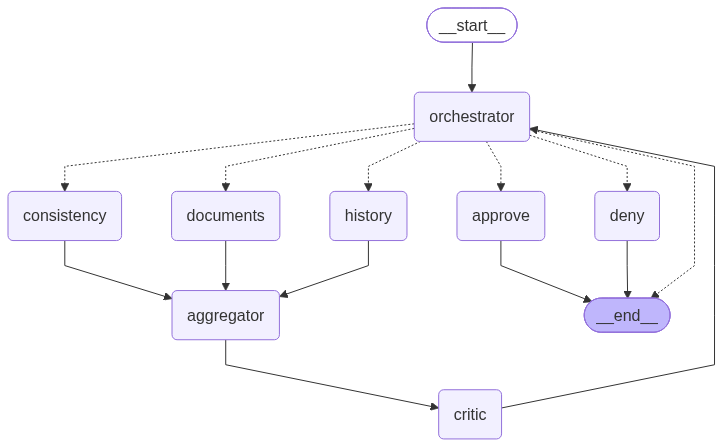

In [25]:
try:
    from IPython.display import Image, display
    display(Image(claim_review_graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(PNG render skipped - falling back to Mermaid source)")
    print(claim_review_graph.get_graph().draw_mermaid())


## 10. Run the graph and verify

Checkpointing note: reducers append/merge on resumed threads, so reusing the same `thread_id` can accumulate prior audit state. Use a fresh thread per run.



In [26]:
def build_initial_claim_state(claim: dict, reference_date: Optional[date] = None) -> State:
    """Build a fresh LangGraph state object for a single claim."""

    resolved_reference_date = (reference_date or datetime.now(timezone.utc).date()).isoformat()

    return {
        "claim": claim,
        "claim_id": claim["claim_id"],
        "reference_date": resolved_reference_date,
        "worker_results": {},
        "aggregated_report": None,
        "risk_score": None,
        "evaluation_status": "unscored",
        "critic_decision": None,
        "target_worker": None,
        "retry_count": 0,
        "audit_log": [],
        "final_verdict": None,
    }


async def run_claim_workflow(claim: dict, compiled_graph=None, thread_id: Optional[str] = None, reference_date: Optional[date] = None) -> dict:
    """Run a claim through the graph and return the final state."""

    graph_ref = compiled_graph or claim_review_graph
    cid = claim["claim_id"]
    config = {
        "configurable": {"thread_id": thread_id or f"{cid}-{uuid.uuid4().hex[:8]}"},
        "recursion_limit": 50,
    }
    return await graph_ref.ainvoke(build_initial_claim_state(claim, reference_date=reference_date), config=config)


def summarize_claim_run(result: dict) -> None:
    """Print a compact summary of one run's result."""

    score = result.get("risk_score")
    print(f"  claim_id       : {result['claim_id']}")
    print(f"  final_verdict  : {result['final_verdict']}")
    print(f"  eval_status    : {result.get('evaluation_status')}")
    print(
        f"  risk_score     : {score:.2f}" if isinstance(score, (int, float)) else "  risk_score     : (none)"
    )
    print(f"  retry_count    : {result['retry_count']}")
    print(f"  failed_workers : {result['aggregated_report']['failed_workers']}")
    print(f"  audit entries  : {len(result['audit_log'])}")


### Validation checks - end-to-end paths

The checks assert **structural** properties (graph completion, state population, retry-cap compliance), not exact risk scores; numeric LLM output is not part of the contract.



In [27]:
# ---- Validation 7: end-to-end execution sanity on a reference claim ---------------
_reference_result = await run_claim_workflow(_claims.iloc[0].to_dict())
assert _reference_result["final_verdict"] in ("APPROVE", "DENY")
assert _reference_result["retry_count"] <= MAX_RETRIES
assert len(_reference_result["audit_log"]) >= 7, _reference_result["audit_log"]
print("PASS  test_end_to_end_reference_structural")
summarize_claim_run(_reference_result)

PASS  test_end_to_end_reference_structural
  claim_id       : CLM-4001
  final_verdict  : APPROVE
  eval_status    : scored
  risk_score     : 0.20
  retry_count    : 0
  failed_workers : []
  audit entries  : 8


In [28]:
# ---- Validation 8: end-to-end on a seeded suspicious-pattern claim (structural assertions) ----
# Note: CLAIMS[2] is seeded with synthetic red flags in fabricated data, but verdict and score can vary across runs.
_seeded_result = await run_claim_workflow(_claims.iloc[2].to_dict())
assert _seeded_result["final_verdict"] in ("APPROVE", "DENY")
assert _seeded_result["retry_count"] <= MAX_RETRIES
assert len(_seeded_result["audit_log"]) >= 7
print("PASS  test_end_to_end_seeded_structural")
summarize_claim_run(_seeded_result)

PASS  test_end_to_end_seeded_structural
  claim_id       : CLM-4003
  final_verdict  : DENY
  eval_status    : scored
  risk_score     : 0.50
  retry_count    : 0
  failed_workers : []
  audit entries  : 8


In [29]:
# ---- Validation 9: retry cap enforcement -----------------------------------------
_retry_probe_result = await run_claim_workflow(_claims.iloc[4].to_dict())
assert _retry_probe_result["retry_count"] <= MAX_RETRIES
assert _retry_probe_result["final_verdict"] in ("APPROVE", "DENY")
print("PASS  test_retry_cap")

# ---- Validation 10: one worker timeout -------------------------------------------
_original_timeout = WORKER_TIMEOUT_SEC
WORKER_TIMEOUT_SEC = 1


async def _slow_history_body(_state: State) -> dict:
    """Validation utility: sleep long enough to trigger the timeout wrapper."""

    await asyncio.sleep(2)
    return {"risk_signal": 0.5, "notes": "synthetic delay"}


_timeout_result = await run_claim_workflow(
    _claims.iloc[0].to_dict(),
    compiled_graph=build_claim_review_graph(history_node=make_local_worker_test_node("history", _slow_history_body)),
)
WORKER_TIMEOUT_SEC = _original_timeout
assert _timeout_result["worker_results"]["history"]["status"] == "timeout"
print("PASS  test_one_worker_timeout")

# ---- Validation 11: two workers fail -> quorum deny ------------------------------


async def _boom_history(_state: State) -> dict:
    """Validation utility: raise to simulate a worker crash."""

    raise RuntimeError("forced history failure")


async def _boom_documents(_state: State) -> dict:
    """Validation utility: raise to simulate a worker crash."""

    raise RuntimeError("forced docs failure")


_quorum_result = await run_claim_workflow(
    _claims.iloc[0].to_dict(),
    compiled_graph=build_claim_review_graph(
        history_node=make_local_worker_test_node("history", _boom_history),
        documents_node=make_local_worker_test_node("documents", _boom_documents),
    ),
)
assert _quorum_result["final_verdict"] == "DENY"
assert _quorum_result["evaluation_status"] == "insufficient_evidence"
assert _quorum_result["risk_score"] is None
assert (
    next(e for e in _quorum_result["audit_log"] if e["node"] == "aggregator")["output"].get("reason")
    == "insufficient_evidence"
)
print("PASS  test_quorum_fail_safe")

# ---- Validation 12: MCP unreachable -> worker error ------------------------------


async def _broken_mcp_history_body(state: State) -> dict:
    """Validation utility: call a non-existent MCP port to simulate an unreachable tool."""

    await mcp_call(8899, "get_claim_history", {"policyholder_id": state["claim"]["policyholder_id"]})
    return {"risk_signal": 0.0, "notes": "should not get here"}


_broken = await run_claim_workflow(
    _claims.iloc[0].to_dict(),
    compiled_graph=build_claim_review_graph(history_node=make_local_worker_test_node("history", _broken_mcp_history_body)),
)
assert _broken["worker_results"]["history"]["status"] == "error"
print("PASS  test_mcp_unreachable_handled")

# ---- Validation 13: malformed critic payload -------------------------------------
MALFORM_CRITIC_PAYLOAD = True
_malformed = await run_claim_workflow(_claims.iloc[0].to_dict())
MALFORM_CRITIC_PAYLOAD = False
assert _malformed["final_verdict"] == "DENY"
assert _malformed["evaluation_status"] == "critic_error"
assert _malformed["risk_score"] is None
assert any(e["node"] == "critic:error" for e in _malformed["audit_log"])
print("PASS  test_malformed_critic_payload_safe")

# ---- Validation 14: reducer safety with fresh thread IDs -------------------------


async def fixed_critic_node_fn(state: State) -> dict:
    """Validation utility: deterministic critic node to validate reducer behaviour."""

    verdict = {
        "risk_score": 0.1,
        "decision": "approve",
        "target_worker": None,
        "rationale": "fixed",
    }
    return {
        "risk_score": verdict["risk_score"],
        "evaluation_status": "scored",
        "critic_decision": verdict["decision"],
        "target_worker": verdict["target_worker"],
        "audit_log": [audit("critic", verdict, state.get("retry_count", 0))],
    }


_deterministic_graph = build_claim_review_graph(critic_node_callable=fixed_critic_node_fn)
_same_claim = _claims.iloc[0].to_dict()
_r1 = await run_claim_workflow(
    _same_claim,
    compiled_graph=_deterministic_graph,
    thread_id=f"{_same_claim['claim_id']}-{uuid.uuid4().hex[:8]}",
)
_r2 = await run_claim_workflow(
    _same_claim,
    compiled_graph=_deterministic_graph,
    thread_id=f"{_same_claim['claim_id']}-{uuid.uuid4().hex[:8]}",
)
assert len(_r1["audit_log"]) == len(_r2["audit_log"])
print("PASS  test_reducer_safety_fresh_thread_ids")

PASS  test_retry_cap
PASS  test_one_worker_timeout
PASS  test_quorum_fail_safe
PASS  test_mcp_unreachable_handled
PASS  test_malformed_critic_payload_safe
PASS  test_reducer_safety_fresh_thread_ids


### Run all 10 claims and tabulate



In [30]:
claim_run_summaries = []
claim_run_results = []

for i, claim_series in _claims.iterrows():
    claim = claim_series.to_dict()
    run_result = await run_claim_workflow(claim)
    claim_run_results.append(run_result)

    score = run_result.get("risk_score")
    claim_run_summaries.append({
        "claim_id":          run_result["claim_id"],
        "policyholder":      claim["policyholder_id"],
        "shop":              claim["repair_shop_id"],
        "amount":            claim["amount"],
        "evaluation_status": run_result.get("evaluation_status"),
        "risk_score":       (round(float(score), 2) if isinstance(score, (int, float)) else None),
        "retry_count":       run_result["retry_count"],
        "final_verdict":     run_result["final_verdict"],
    })

results_df = pd.DataFrame(claim_run_summaries)
results_df

,claim_id,policyholder,shop,amount,evaluation_status,risk_score,retry_count,final_verdict
0,CLM-4001,PH-100,SHOP-001,2800,scored,0.2,0,APPROVE
1,CLM-4002,PH-500,SHOP-003,3400,scored,0.2,0,APPROVE
2,CLM-4003,PH-300,SHOP-999,14500,scored,0.5,0,DENY
3,CLM-4004,PH-999,SHOP-999,9500,scored,0.7,0,DENY
4,CLM-4005,PH-200,SHOP-002,4900,scored,0.2,0,APPROVE
5,CLM-4006,PH-700,SHOP-001,6200,scored,0.8,0,DENY
6,CLM-4007,PH-400,SHOP-004,1900,scored,0.5,0,DENY
7,CLM-4008,PH-800,SHOP-005,3600,scored,0.2,0,APPROVE
8,CLM-4009,PH-600,SHOP-002,5100,scored,0.2,0,APPROVE
9,CLM-4010,PH-900,SHOP-003,7800,scored,0.1,0,APPROVE


## 11. Audit trail - one claim in full

The audit log is the append-only trace of every node's contribution, powered by the `Annotated[list, operator.add]` reducer.

The next step auto-selects one claim with a transparent ranking:
1. Prefer non-standard evaluation paths (`insufficient_evidence` / `critic_error`).
2. Then prefer higher `retry_count`.
3. Then prefer higher `risk_score` (if available).
4. Then prefer longer audit trails.


In [31]:
def print_claim_audit_trail(result: dict) -> None:
    """Pretty-print the audit trail from a completed claim run."""

    score = result.get("risk_score")
    score_str = f"{score:.2f}" if isinstance(score, (int, float)) else "(none)"

    print()
    print(f"=== {result['claim_id']} - {result['final_verdict']} (risk_score={score_str}) ===")

    for i, entry in enumerate(result["audit_log"]):
        preview = json.dumps(entry["output"])[:110]
        print(f"  {i:2d}. [retry={entry['retry_iteration']}] {entry['node']:<22} {preview}")


def select_audit_focus_claim(candidates: list[dict]) -> tuple[dict, str]:
    """Select one claim for audit with an explicit, reproducible ranking policy."""

    if not candidates:
        raise ValueError("No claim results available for audit selection")

    def ranking_key(result: dict) -> tuple:
        status = result.get("evaluation_status")
        retry_count = int(result.get("retry_count", 0) or 0)
        risk_score = result.get("risk_score")
        numeric_score = float(risk_score) if isinstance(risk_score, (int, float)) else -1.0
        audit_len = len(result.get("audit_log", []))

        # Smaller bucket is more interesting.
        if status in ("insufficient_evidence", "critic_error"):
            bucket = 0
        elif retry_count > 0:
            bucket = 1
        else:
            bucket = 2

        # sort key: bucket asc, then retry/fraud/audit desc, then claim_id asc
        return (bucket, -retry_count, -numeric_score, -audit_len, result.get("claim_id", ""))

    selected = sorted(candidates, key=ranking_key)[0]

    status = selected.get("evaluation_status")
    if status in ("insufficient_evidence", "critic_error"):
        reason = f"selected non-standard path ({status})"
    elif selected.get("retry_count", 0) > 0:
        reason = f"selected retry-heavy path (retry_count={selected['retry_count']})"
    elif isinstance(selected.get("risk_score"), (int, float)):
        reason = f"selected highest-risk scored path (risk_score={selected['risk_score']:.2f})"
    else:
        reason = "selected by tie-breaker (audit length / claim_id)"

    return selected, reason


interesting_result, interesting_reason = select_audit_focus_claim(claim_run_results)
print(f"Auto-picked claim for audit: {interesting_result['claim_id']} ({interesting_reason})")
print_claim_audit_trail(interesting_result)


Auto-picked claim for audit: CLM-4006 (selected highest-risk scored path (risk_score=0.80))

=== CLM-4006 - DENY (risk_score=0.80) ===
   0. [retry=0] orchestrator:dispatch  {"claim_id": "CLM-4006"}
   1. [retry=0] consistency            {"status": "ok", "risk_signal": 0.8, "notes": "Observations: The claim narrative describes damage consistent w
   2. [retry=0] documents              {"status": "ok", "risk_signal": 0.0, "notes": "No anomalies found. Evidence references: Anomaly Indicator Coun
   3. [retry=0] history                {"status": "ok", "risk_signal": 0.0, "notes": "No claims have been recorded for this policyholder. As there is
   4. [retry=0] aggregator             {"successful": ["consistency", "history", "documents"], "failed": [], "quorum_failed": false}
   5. [retry=0] critic                 {"risk_score": 0.8, "decision": "deny", "target_worker": null, "rationale": "The claim is denied due to a sign
   6. [retry=0] orchestrator:review    {"decision": "deny", "retry_c

## 12. Recap and limitations

**Key implementation outcomes**
- MAS-style layout: deterministic orchestrator + three remote worker services + remote critic service.
- Parallel fan-out in LangGraph, where each worker node is an A2A client adapter to its worker service.
- Real MCP SDK usage (`mcp==1.12.4`) over streamable-HTTP; this implementation explicitly calls `session.initialize()` in the MCP helper.
- Real A2A SDK usage (`a2a-sdk==1.1.2`) with Agent Card discovery, task execution, and artifact return.
- Bounded re-evaluation loop (`MAX_RETRIES = 2`) and conservative cap-hit handling.
- Partial-failure tolerance via timeout wrapper + aggregator quorum.
- Explicit worker role contracts (responsibility, tools, evidence criteria, output contract, limitations).
- Critic with explicit disagreement/evidence-gap responsibilities and retry-normalization guardrails.

**Limitations and Further Improvement**
- `risk_score` is an LLM-generated heuristic risk signal, **not** a calibrated fraud probability.
- Some fallback paths can produce `final_verdict="DENY"` without a meaningful `risk_score` (e.g. insufficient evidence or critic failures).
- The retry loop is a **bounded workflow control**, not online learning.
- The orchestrator is deterministic workflow code in this implementation; orchestrators can be deterministic code or agents.
- MAS is not defined by parallelism alone; the MAS framing in this implementation comes from specialized services + A2A boundaries + coordinated orchestration.
- `AggregatedClaimReport` is a fixed-shape `TypedDict` (static typing), with runtime checks implemented in workflow logic.
- Localhost runtime scope excludes authn/authz and secure transport layers; production systems should enforce both.
- The PDF checks are **synthetic consistency signals** and do not constitute document-forensics evidence.


In [32]:
# ---- Shutdown local MCP + A2A services -------------------------------------
# Run this at the end to free ports.
#
# Note: MCP `FastMCP(...).streamable_http_app()` uses an internal session manager
# that is designed to run once per process. If MCP servers are stopped and need
# to start them again, restart the notebook kernel/runtime.


def _stop_uvicorn(server, thread, label: str, timeout: float = 5.0) -> None:
    """Stop a background uvicorn server thread started by `serve_in_thread()`."""

    if server is None or thread is None:
        return
    if not thread.is_alive():
        return

    server.should_exit = True
    thread.join(timeout=timeout)

    if thread.is_alive():
        server.force_exit = True
        thread.join(timeout=timeout)

    status = "stopped" if not thread.is_alive() else "still running"
    print(f"[DOWN] {label:<16} {status}")


_stop_uvicorn(globals().get("_policy_server"), globals().get("_policy_thread"), "policy-server")
_stop_uvicorn(globals().get("_doc_server"), globals().get("_doc_thread"), "doc-server")
_stop_uvicorn(globals().get("_consistency_agent_server"), globals().get("_consistency_agent_thread"), "consistency-agent")
_stop_uvicorn(globals().get("_history_agent_server"), globals().get("_history_agent_thread"), "history-agent")
_stop_uvicorn(globals().get("_documents_agent_server"), globals().get("_documents_agent_thread"), "documents-agent")
_stop_uvicorn(globals().get("_critic_server"), globals().get("_critic_thread"), "critic-agent")

# Drop references to make re-runs less confusing.
_policy_server = _policy_thread = None
_doc_server = _doc_thread = None
_consistency_agent_server = _consistency_agent_thread = None
_history_agent_server = _history_agent_thread = None
_documents_agent_server = _documents_agent_thread = None
_critic_server = _critic_thread = None


[DOWN] policy-server    stopped
[DOWN] doc-server       stopped
[DOWN] consistency-agent stopped
[DOWN] history-agent    stopped
[DOWN] documents-agent  stopped
[DOWN] critic-agent     stopped
